# F4_Definicion_FINAL — Proyecto Final Integrador

**Proyecto:** Análisis reproducible del Mundial FIFA Qatar 2022  
**Curso:** MCDI500 — Programación para la Ciencia de Datos  
**Fase:** Sumativa 4 — Integración F1, F2, F3 y F4  
**Integrantes:** Luis Rodrigo Espinoza, Claudio Alarcón, Enzo Pinilla  

Este notebook consolida el trabajo desarrollado en F1, F2 y F3, y agrega la comunicación analítica solicitada en F4: visualizaciones finales, storytelling, resultados, discusión, conclusiones, validación técnica y trazabilidad de mejoras.


## Índice

1. [Introducción y contextualización](#1)
2. [Definición de la problemática y objetivos](#2)
3. [Aplicación de herramientas científicas y reproducibilidad](#3)
4. [Diseño de soluciones algorítmicas eficientes](#4)
   - 4.1. Codificación funcional y arquitectura
   - 4.2. Preprocesamiento y transformación del dataset
   - 4.3. Validación técnica y verificación del código
   - 4.4. Eficiencia y optimización (benchmarks con `timeit`)
   - 4.5. Diseño estructurado y recursividad
5. [Implementación de código modular y robusto (POO)](#5)
6. [Construcción de visualizaciones de datos efectivas](#6)
7. [Metodología, trazabilidad de mejoras y *changelog*](#7)
8. [Resultados y discusión](#8)
9. [Conclusiones y reflexión crítica](#9)
10. [Bibliografía (APA 7)](#10)


<a id="1"></a>
## 1. Introducción y contextualización

Este notebook corresponde a la **Fase 4 del proyecto final integrador** del curso MCDI500. Su propósito es consolidar las fases F1, F2 y F3 en una evidencia ejecutable, reproducible y comunicable.

El proyecto analiza datos del Mundial FIFA Qatar 2022 para explorar patrones asociados al rendimiento de las selecciones. La Fase 4 no reemplaza las fases anteriores: las integra y mejora. Por eso este notebook mantiene la progresión completa del proyecto: definición del problema, preparación del dataset, desarrollo algorítmico, mediciones de eficiencia, programación orientada a objetos y comunicación final mediante visualizaciones.


<a id="2"></a>
## 2. Definición de la problemática y objetivos

**Problemática.** El rendimiento de una selección en un partido de fútbol depende de múltiples estadísticas. Sin un flujo reproducible, limpio y validado, es difícil interpretar esas variables de manera consistente.

**Pregunta orientadora.** ¿Qué estadísticas de juego se asocian con el desempeño y la victoria de una selección durante la Copa Mundial FIFA Qatar 2022?

**Objetivo general.** Desarrollar un análisis reproducible del Mundial FIFA Qatar 2022 mediante Python, Jupyter, pandas, NumPy, visualizaciones y técnicas algorítmicas, para identificar patrones asociados al rendimiento de las selecciones.

**Objetivos específicos.**

1. Definir el problema, alcance, supuestos y flujo reproducible del proyecto.
2. Cargar, explorar, limpiar y transformar el dataset.
3. Implementar funciones, algoritmos iterativos, recursivos y vectorizados.
4. Medir eficiencia con `timeit` y justificar decisiones técnicas.
5. Aplicar programación orientada a objetos para modularizar el procesamiento.
6. Construir visualizaciones con Seaborn/Matplotlib e interpretar hallazgos.
7. Documentar resultados, limitaciones, conclusiones y trazabilidad de mejoras.


<a id="3"></a>
## 3. Aplicación de herramientas científicas y reproducibilidad

Se utiliza el ecosistema científico de Python:

- **pandas:** carga, limpieza, transformación y análisis tabular.
- **NumPy:** operaciones numéricas y validaciones.
- **Matplotlib/Seaborn:** visualización de resultados.
- **timeit:** mediciones reproducibles de eficiencia.
- **Jupyter Notebook:** documentación ejecutable.
- **Git/GitHub:** control de versiones, trazabilidad y colaboración.

El notebook está diseñado para ejecutarse desde la raíz del repositorio o desde una carpeta `notebooks/`. Si no encuentra el CSV real, genera un dataset demo con la misma lógica de columnas principales. Esto permite validar el flujo técnico sin romper la ejecución, aunque la entrega final debe ejecutarse con el dataset real del repositorio.


In [1]:
from __future__ import annotations

import sys
import timeit
import platform
from pathlib import Path
from abc import ABC, abstractmethod
from typing import Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

CURRENT_DIR = Path.cwd()


def buscar_raiz_proyecto(inicio: Path) -> Path:
    """Ubica la raíz del repositorio sin depender de una ruta de usuario."""
    for candidato in [inicio, *inicio.parents]:
        if (candidato / "data" / "raw" / "Fifa_world_cup_matches.csv").exists():
            return candidato
        if (candidato / "README.md").exists() and (candidato / "notebooks").exists():
            return candidato
    return inicio.parent if inicio.name.lower() in {"notebooks", "f4"} else inicio


def ruta_repo(ruta: str | Path) -> str:
    """Muestra rutas relativas al repositorio para que el notebook sea portable."""
    ruta = Path(ruta)
    try:
        return ruta.resolve().relative_to(PROJECT_ROOT.resolve()).as_posix()
    except ValueError:
        return ruta.as_posix()


PROJECT_ROOT = buscar_raiz_proyecto(CURRENT_DIR)
DATA_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw" / "Fifa_world_cup_matches.csv",
    PROJECT_ROOT / "F2" / "data" / "raw" / "Fifa_world_cup_matches.csv",
    CURRENT_DIR / "Fifa_world_cup_matches.csv",
]

FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
REPORTS_DIR = PROJECT_ROOT / "results" / "reports"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version.split()[0])
print("Sistema:", platform.platform())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Raíz del proyecto:", ruta_repo(PROJECT_ROOT) or ".")
print("Carpeta de figuras:", ruta_repo(FIGURES_DIR))


Python: 3.10.4
Sistema: macOS-26.5.1-arm64-arm-64bit
pandas: 2.3.3
NumPy: 2.2.6
Raíz del proyecto: .
Carpeta de figuras: results/figures


<a id="4"></a>
## 4. Diseño de soluciones algorítmicas eficientes

### 4.1. Codificación funcional y arquitectura

Esta sección integra la base de F1 y F2: carga de datos, definición del flujo reproducible y funciones reutilizables. La arquitectura mantiene una separación clara entre entrada de datos, transformación, validación, análisis y comunicación de resultados.


In [2]:
def cargar_datos(ruta: str | Path) -> pd.DataFrame:
    """Carga un archivo CSV y valida que exista."""
    ruta = Path(ruta)
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo: {ruta}")
    return pd.read_csv(ruta)


def crear_dataset_demo(n_partidos: int = 64, semilla: int = SEED) -> pd.DataFrame:
    """Crea un dataset demo de respaldo con columnas similares al dataset FIFA.

    Este respaldo permite ejecutar el notebook aunque el CSV real no esté disponible.
    No reemplaza el análisis con datos reales en la entrega final del repositorio.
    """
    rng = np.random.default_rng(semilla)
    equipos = np.array([
        "Argentina", "Francia", "Croacia", "Marruecos", "Brasil", "Países Bajos",
        "Portugal", "Inglaterra", "España", "Japón", "Senegal", "Estados Unidos",
        "México", "Uruguay", "Alemania", "Canadá"
    ])
    team1 = rng.choice(equipos, size=n_partidos)
    team2 = rng.choice(equipos, size=n_partidos)
    iguales = team1 == team2
    while iguales.any():
        team2[iguales] = rng.choice(equipos, size=iguales.sum())
        iguales = team1 == team2

    goals1 = rng.poisson(1.4, size=n_partidos)
    goals2 = rng.poisson(1.1, size=n_partidos)
    poss1 = rng.integers(35, 66, size=n_partidos)
    poss2 = 100 - poss1

    return pd.DataFrame({
        "team1": team1,
        "team2": team2,
        "number of goals team1": goals1,
        "number of goals team2": goals2,
        "possession team1": [f"{v}%" for v in poss1],
        "possession team2": [f"{v}%" for v in poss2],
        "total attempts team1": goals1 + rng.integers(4, 18, size=n_partidos),
        "total attempts team2": goals2 + rng.integers(4, 18, size=n_partidos),
        "passes team1": rng.integers(250, 850, size=n_partidos),
        "passes team2": rng.integers(250, 850, size=n_partidos),
        "fouls against team1": rng.integers(5, 22, size=n_partidos),
        "fouls against team2": rng.integers(5, 22, size=n_partidos),
        "category": rng.choice(["Group", "Round of 16", "Quarter-final", "Semi-final", "Final"], size=n_partidos),
    })


def cargar_dataset_proyecto() -> tuple[pd.DataFrame, str]:
    """Busca el dataset real en rutas habituales. Si no existe, usa respaldo demo."""
    for ruta in DATA_CANDIDATES:
        if ruta.exists():
            return cargar_datos(ruta), f"CSV real: {ruta_repo(ruta)}"
    return crear_dataset_demo(), "Dataset demo generado por respaldo reproducible"


df_raw, fuente_datos = cargar_dataset_proyecto()
print(fuente_datos)
print("Dimensiones iniciales:", df_raw.shape)
df_raw.head()


CSV real: data/raw/Fifa_world_cup_matches.csv
Dimensiones iniciales: (64, 88)


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,penalties scored team1,penalties scored team2,goal preventions team1,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2
0,QATAR,ECUADOR,42%,50%,8%,0,2,20 NOV 2022,17 : 00,Group A,...,0,1,6,5,0,0,52,72,256,279
1,ENGLAND,IRAN,72%,19%,9%,6,2,21 NOV 2022,14 : 00,Group B,...,0,1,8,13,0,0,63,72,139,416
2,SENEGAL,NETHERLANDS,44%,45%,11%,0,2,21 NOV 2022,17 : 00,Group A,...,0,0,9,15,0,0,63,73,263,251
3,UNITED STATES,WALES,51%,39%,10%,1,1,21 NOV 2022,20 : 00,Group B,...,0,1,7,7,0,0,81,72,242,292
4,ARGENTINA,SAUDI ARABIA,64%,24%,12%,1,2,22 NOV 2022,11 : 00,Group C,...,1,0,4,14,0,0,65,80,163,361


**Interpretación F1.** La carga inicial permite confirmar que existe una fuente de datos tabular y que el análisis puede organizarse como un flujo reproducible: entrada de datos, preparación, validación, análisis y comunicación de resultados.


### 4.2. Preprocesamiento y transformación del dataset

En esta etapa se construye el pipeline de preprocesamiento. El objetivo es convertir el dataset original en una tabla consistente, validada y apta para análisis posteriores. Incluye normalización de nombres, conversión de porcentajes, tratamiento de valores nulos, codificación y generación de variables derivadas.


In [3]:
def normalizar_nombres_columnas(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza nombres de columnas para facilitar su uso en el pipeline."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ", regex=False)
        .str.replace(r"\s+", " ", regex=True)
    )
    return df


def convertir_porcentaje(df: pd.DataFrame, columna: str) -> pd.DataFrame:
    """Convierte una columna con porcentajes en texto a valores numéricos."""
    if columna not in df.columns:
        raise ValueError(f"La columna {columna} no existe.")
    df = df.copy()
    df[columna] = pd.to_numeric(
        df[columna].astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )
    return df


def crear_variables_resultado(df: pd.DataFrame) -> pd.DataFrame:
    """Crea variables derivadas: goles totales, diferencia y resultado del equipo 1."""
    df = df.copy()
    g1 = "number of goals team1"
    g2 = "number of goals team2"
    if not {g1, g2}.issubset(df.columns):
        raise ValueError("Faltan columnas de goles para crear variables de resultado.")
    df[g1] = pd.to_numeric(df[g1], errors="coerce").fillna(0).astype(int)
    df[g2] = pd.to_numeric(df[g2], errors="coerce").fillna(0).astype(int)
    df["total goals match"] = df[g1] + df[g2]
    df["goal difference team1"] = df[g1] - df[g2]
    df["result team1"] = np.where(df[g1] > df[g2], "win", np.where(df[g1] < df[g2], "loss", "draw"))
    return df


def codificar_categoricas(df: pd.DataFrame, max_categorias: int = 12) -> pd.DataFrame:
    """Codifica columnas categóricas de baja cardinalidad mediante one-hot encoding."""
    df = df.copy()
    candidatas = []
    for col in df.select_dtypes(include="object").columns:
        if df[col].nunique(dropna=True) <= max_categorias:
            candidatas.append(col)
    if candidatas:
        df = pd.get_dummies(df, columns=candidatas, drop_first=False, dtype=int)
    return df


def pipeline_preprocesamiento(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Pipeline completo F2: limpieza, casting, variables derivadas, codificación y validación."""
    metadata = {
        "filas_iniciales": len(df),
        "columnas_iniciales": len(df.columns),
        "porcentajes_convertidos": [],
        "columnas_eliminadas_no_numericas": [],
    }
    dfp = normalizar_nombres_columnas(df)
    dfp = dfp.drop_duplicates().copy()

    for col in list(dfp.columns):
        if dfp[col].dtype == "object" and dfp[col].astype(str).str.contains("%", regex=False).any():
            dfp = convertir_porcentaje(dfp, col)
            metadata["porcentajes_convertidos"].append(col)

    if {"number of goals team1", "number of goals team2"}.issubset(dfp.columns):
        dfp = crear_variables_resultado(dfp)

    # Imputación simple y trazable.
    for col in dfp.select_dtypes(include=np.number).columns:
        dfp[col] = dfp[col].fillna(dfp[col].median())
    for col in dfp.select_dtypes(include="object").columns:
        dfp[col] = dfp[col].fillna("sin_dato")

    # Versión para análisis algorítmico y visual: mantenemos team1/team2 en df_limpio.
    df_limpio = dfp.copy()

    # Versión numérica para validación técnica del pipeline.
    df_num = codificar_categoricas(dfp)
    no_numericas = df_num.select_dtypes(exclude=np.number).columns.tolist()
    metadata["columnas_eliminadas_no_numericas"] = no_numericas
    df_num = df_num.drop(columns=no_numericas, errors="ignore")

    # Escalamiento manual tipo z-score para variables continuas, evitando columnas binarias.
    for col in df_num.select_dtypes(include=np.number).columns:
        serie = df_num[col].astype(float)
        if serie.nunique(dropna=True) > 2 and serie.std(ddof=0) > 0:
            df_num[col] = (serie - serie.mean()) / serie.std(ddof=0)

    metadata["filas_finales"] = len(df_num)
    metadata["columnas_finales"] = len(df_num.columns)
    return df_limpio, df_num, metadata


df_limpio, df_procesado, metadata_f2 = pipeline_preprocesamiento(df_raw)
metadata_f2


{'filas_iniciales': 64,
 'columnas_iniciales': 88,
 'porcentajes_convertidos': ['possession team1',
  'possession team2',
  'possession in contest'],
 'columnas_eliminadas_no_numericas': ['team1', 'team2', 'date', 'category'],
 'filas_finales': 64,
 'columnas_finales': 93}

In [4]:
print("Dimensiones dataset limpio:", df_limpio.shape)
print("Dimensiones dataset numérico procesado:", df_procesado.shape)
print("Valores nulos en dataset procesado:", int(df_procesado.isna().sum().sum()))
print("Duplicados dataset limpio:", int(df_limpio.duplicated().sum()))
df_limpio.head()


Dimensiones dataset limpio: (64, 91)
Dimensiones dataset numérico procesado: (64, 93)
Valores nulos en dataset procesado: 0
Duplicados dataset limpio: 0


,team1,team2,possession team1,possession team2,possession in contest,number of goals team1,number of goals team2,date,hour,category,...,goal preventions team2,own goals team1,own goals team2,forced turnovers team1,forced turnovers team2,defensive pressures applied team1,defensive pressures applied team2,total goals match,goal difference team1,result team1
0,QATAR,ECUADOR,42,50,8,0,2,20 NOV 2022,17 : 00,Group A,...,5,0,0,52,72,256,279,2,-2,loss
1,ENGLAND,IRAN,72,19,9,6,2,21 NOV 2022,14 : 00,Group B,...,13,0,0,63,72,139,416,8,4,win
2,SENEGAL,NETHERLANDS,44,45,11,0,2,21 NOV 2022,17 : 00,Group A,...,15,0,0,63,73,263,251,2,-2,loss
3,UNITED STATES,WALES,51,39,10,1,1,21 NOV 2022,20 : 00,Group B,...,7,0,0,81,72,242,292,2,0,draw
4,ARGENTINA,SAUDI ARABIA,64,24,12,1,2,22 NOV 2022,11 : 00,Group C,...,14,0,0,65,80,163,361,3,-1,loss


### 4.3. Validación técnica y verificación del código

La validación comprueba que el dataset procesado conserva registros, no contiene nulos y queda en formato numérico para análisis algorítmico. También se prueban casos normales, casos límite y excepciones.


In [5]:
def validar_dataset(df: pd.DataFrame) -> bool:
    """Valida condiciones mínimas de integridad para el dataset procesado."""
    if df.empty:
        raise ValueError("El dataset está vacío.")
    if df.isna().sum().sum() != 0:
        raise ValueError("El dataset contiene valores nulos.")
    if len(df.select_dtypes(exclude=np.number).columns) > 0:
        raise ValueError("El dataset procesado contiene columnas no numéricas.")
    return True

# Caso normal
assert validar_dataset(df_procesado) is True

# Caso límite: dataframe vacío
try:
    validar_dataset(pd.DataFrame())
except ValueError as exc:
    print("Caso límite controlado:", exc)

# Caso de excepción: columna no numérica
try:
    validar_dataset(pd.DataFrame({"texto": ["a", "b"]}))
except ValueError as exc:
    print("Excepción controlada:", exc)

print("Validaciones F2 completadas correctamente.")


Caso límite controlado: El dataset está vacío.
Excepción controlada: El dataset procesado contiene columnas no numéricas.
Validaciones F2 completadas correctamente.


### 4.4. Eficiencia y optimización (benchmarks con `timeit`)

Esta sección integra el trabajo de F3. Se implementan soluciones algorítmicas para sumar goles y ordenar selecciones por rendimiento ofensivo. Se comparan enfoques iterativos, recursivos, vectorizados y funciones optimizadas, utilizando mediciones reproducibles con `timeit`.


In [6]:
def preparar_lista_goles(df: pd.DataFrame) -> list[int]:
    """Extrae los goles de ambos equipos como lista de enteros."""
    requeridas = ["number of goals team1", "number of goals team2"]
    faltantes = [col for col in requeridas if col not in df.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas de goles: {faltantes}")
    goles = pd.concat([
        pd.to_numeric(df["number of goals team1"], errors="coerce"),
        pd.to_numeric(df["number of goals team2"], errors="coerce"),
    ]).fillna(0).astype(int).tolist()
    return goles


def suma_iterativa(valores: Sequence[int]) -> int:
    """Suma una secuencia usando un ciclo explícito. Complejidad O(n)."""
    total = 0
    for valor in valores:
        total += int(valor)
    return total


def suma_recursiva(valores: Sequence[int]) -> int:
    """Suma una secuencia mediante recursividad. Complejidad O(n), espacio O(n)."""
    valores = list(valores)
    if len(valores) == 0:
        return 0
    return int(valores[0]) + suma_recursiva(valores[1:])


def suma_vectorizada_pandas(df: pd.DataFrame) -> int:
    """Suma goles usando operaciones vectorizadas de pandas."""
    return int(
        pd.to_numeric(df["number of goals team1"], errors="coerce").fillna(0).sum()
        + pd.to_numeric(df["number of goals team2"], errors="coerce").fillna(0).sum()
    )


goles = preparar_lista_goles(df_limpio)
resultado_iterativo = suma_iterativa(goles)
resultado_recursivo = suma_recursiva(goles)
resultado_vectorizado = suma_vectorizada_pandas(df_limpio)

print("Iterativo:", resultado_iterativo)
print("Recursivo:", resultado_recursivo)
print("Vectorizado:", resultado_vectorizado)

assert resultado_iterativo == resultado_recursivo == resultado_vectorizado
assert len(goles) == df_limpio.shape[0] * 2
assert resultado_iterativo >= 0
print("Algoritmos de suma validados correctamente.")


Iterativo: 172
Recursivo: 172
Vectorizado: 172
Algoritmos de suma validados correctamente.


In [7]:
def obtener_goles_por_equipo(df: pd.DataFrame) -> list[tuple[str, int]]:
    """Agrupa goles por selección considerando apariciones como team1 y team2."""
    partes = []
    if {"team1", "number of goals team1"}.issubset(df.columns):
        partes.append(pd.DataFrame({"team": df["team1"], "goals": pd.to_numeric(df["number of goals team1"], errors="coerce").fillna(0).astype(int)}))
    if {"team2", "number of goals team2"}.issubset(df.columns):
        partes.append(pd.DataFrame({"team": df["team2"], "goals": pd.to_numeric(df["number of goals team2"], errors="coerce").fillna(0).astype(int)}))
    if not partes:
        raise ValueError("No existen columnas suficientes para calcular goles por equipo.")
    ranking = pd.concat(partes).groupby("team", as_index=False)["goals"].sum()
    return list(ranking.itertuples(index=False, name=None))


def merge_sort_recursivo(items: list[tuple[str, int]]) -> list[tuple[str, int]]:
    """Ordena pares (equipo, goles) de mayor a menor mediante merge sort recursivo."""
    if len(items) <= 1:
        return items
    mitad = len(items) // 2
    izquierda = merge_sort_recursivo(items[:mitad])
    derecha = merge_sort_recursivo(items[mitad:])
    return combinar_ordenado(izquierda, derecha)


def combinar_ordenado(izquierda: list[tuple[str, int]], derecha: list[tuple[str, int]]) -> list[tuple[str, int]]:
    resultado = []
    i = j = 0
    while i < len(izquierda) and j < len(derecha):
        if izquierda[i][1] >= derecha[j][1]:
            resultado.append(izquierda[i])
            i += 1
        else:
            resultado.append(derecha[j])
            j += 1
    resultado.extend(izquierda[i:])
    resultado.extend(derecha[j:])
    return resultado


def ordenar_builtin(items: list[tuple[str, int]]) -> list[tuple[str, int]]:
    """Ordenamiento de referencia usando sorted de Python."""
    return sorted(items, key=lambda x: x[1], reverse=True)


goles_por_equipo = obtener_goles_por_equipo(df_limpio)
ranking_merge = merge_sort_recursivo(goles_por_equipo)
ranking_builtin = ordenar_builtin(goles_por_equipo)
assert ranking_merge == ranking_builtin
pd.DataFrame(ranking_merge[:10], columns=["team", "goals"])


,team,goals
0,FRANCE,16
1,ARGENTINA,15
2,ENGLAND,13
3,PORTUGAL,12
4,NETHERLANDS,10
5,SPAIN,9
6,BRAZIL,8
7,CROATIA,8
8,GERMANY,6
9,MOROCCO,6


#### Benchmarks reproducibles

Se comparan implementaciones equivalentes. La comparación no solo mide el tiempo, también permite justificar la elección técnica considerando complejidad temporal y espacial.


In [8]:
repeticiones_suma = 1000
repeticiones_orden = 1000

tiempos = {
    "suma_iterativa": timeit.timeit(lambda: suma_iterativa(goles), number=repeticiones_suma),
    "suma_recursiva": timeit.timeit(lambda: suma_recursiva(goles), number=repeticiones_suma),
    "suma_vectorizada_pandas": timeit.timeit(lambda: suma_vectorizada_pandas(df_limpio), number=repeticiones_suma),
    "merge_sort_recursivo": timeit.timeit(lambda: merge_sort_recursivo(goles_por_equipo), number=repeticiones_orden),
    "sorted_builtin": timeit.timeit(lambda: ordenar_builtin(goles_por_equipo), number=repeticiones_orden),
}

df_tiempos = pd.DataFrame([
    {"implementacion": nombre, "tiempo_segundos": tiempo}
    for nombre, tiempo in tiempos.items()
]).sort_values("tiempo_segundos")
df_tiempos


,implementacion,tiempo_segundos
4,sorted_builtin,0.002195
0,suma_iterativa,0.007209
3,merge_sort_recursivo,0.032511
2,suma_vectorizada_pandas,0.063166
1,suma_recursiva,0.086502


**Interpretación de eficiencia.**

| Implementación | Complejidad temporal | Complejidad espacial | Decisión técnica |
|---|---:|---:|---|
| `suma_iterativa` | O(n) | O(1) | Clara, simple y eficiente para listas pequeñas o medianas. |
| `suma_recursiva` | O(n) | O(n) | Útil para evidenciar recursividad, menos conveniente por la pila de llamadas. |
| `suma_vectorizada_pandas` | O(n) | Interna optimizada | Recomendable en datos tabulares por optimización interna. |
| `merge_sort_recursivo` | O(n log n) | O(n) | Evidencia divide y vencerás. |
| `sorted_builtin` | O(n log n) | O(n) | Opción práctica final por estar optimizada en Python. |


### 4.5. Diseño estructurado y recursividad

El diseño estructurado separa responsabilidades en funciones pequeñas, verificables y reutilizables. La recursividad se evidencia en `suma_recursiva` y `merge_sort_recursivo`, mientras que la solución final prioriza operaciones vectorizadas o funciones internas optimizadas cuando estas presentan mejor desempeño práctico y menor complejidad de mantenimiento.


<a id="5"></a>
## 5. Implementación de código modular y robusto (POO)

La POO se aplica para encapsular el estado del dataset, separar responsabilidades y permitir transformaciones intercambiables mediante herencia y polimorfismo.


In [9]:
class Transformacion(ABC):
    """Interfaz para transformaciones aplicables a un DataFrame."""

    @abstractmethod
    def aplicar(self, df: pd.DataFrame) -> pd.DataFrame:
        """Aplica una transformación y retorna un nuevo DataFrame."""
        raise NotImplementedError


class ImputacionMediana(Transformacion):
    """Transformación concreta: imputa columnas numéricas con la mediana."""

    def aplicar(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for col in df.select_dtypes(include=np.number).columns:
            df[col] = df[col].fillna(df[col].median())
        return df


class ImputacionCero(Transformacion):
    """Transformación concreta: imputa columnas numéricas con cero."""

    def aplicar(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for col in df.select_dtypes(include=np.number).columns:
            df[col] = df[col].fillna(0)
        return df


class PreprocesadorBase:
    """Clase base que encapsula un DataFrame y operaciones comunes."""

    def __init__(self, df: pd.DataFrame):
        self._df = df.copy()  # atributo encapsulado por convención

    def normalizar_columnas(self):
        self._df = normalizar_nombres_columnas(self._df)
        return self

    def aplicar_transformacion(self, transformacion: Transformacion):
        self._df = transformacion.aplicar(self._df)
        return self

    def resultado(self) -> pd.DataFrame:
        return self._df.copy()


class PreprocesadorFIFA(PreprocesadorBase):
    """Clase hija especializada para el dataset FIFA."""

    def preparar(self):
        self.normalizar_columnas()
        if {"number of goals team1", "number of goals team2"}.issubset(self._df.columns):
            self._df = crear_variables_resultado(self._df)
        self.aplicar_transformacion(ImputacionMediana())
        return self


class CalculadorGoles(ABC):
    """Interfaz polimórfica para cálculo de goles."""

    @abstractmethod
    def calcular(self, df: pd.DataFrame) -> int:
        raise NotImplementedError


class CalculadorGolesIterativo(CalculadorGoles):
    def calcular(self, df: pd.DataFrame) -> int:
        return suma_iterativa(preparar_lista_goles(df))


class CalculadorGolesVectorizado(CalculadorGoles):
    def calcular(self, df: pd.DataFrame) -> int:
        return suma_vectorizada_pandas(df)


preprocesador = PreprocesadorFIFA(df_raw).preparar()
df_poo = preprocesador.resultado()

calculadores: list[CalculadorGoles] = [CalculadorGolesIterativo(), CalculadorGolesVectorizado()]
resultados_poo = {calc.__class__.__name__: calc.calcular(df_poo) for calc in calculadores}
resultados_poo


{'CalculadorGolesIterativo': 172, 'CalculadorGolesVectorizado': 172}

In [10]:
assert len(set(resultados_poo.values())) == 1
assert isinstance(preprocesador.resultado(), pd.DataFrame)
print("POO validada: encapsulamiento, herencia y polimorfismo aplicados correctamente.")


POO validada: encapsulamiento, herencia y polimorfismo aplicados correctamente.


<a id="6"></a>
## 6. Construcción de visualizaciones de datos efectivas

La Fase 4 comunica los hallazgos mediante visualizaciones con títulos interpretativos. La secuencia sigue un storytelling: contexto, patrón principal y lectura analítica con límites.

Los gráficos se construyen usando **Seaborn** sobre Matplotlib para mejorar la claridad visual y mantener coherencia con la guía de visualización.


In [11]:
# Dataset auxiliar para visualizaciones por equipo.
df_team1 = pd.DataFrame({
    "team": df_limpio["team1"],
    "goals": pd.to_numeric(df_limpio["number of goals team1"], errors="coerce").fillna(0),
    "attempts": pd.to_numeric(df_limpio.get("total attempts team1", pd.Series(np.nan, index=df_limpio.index)), errors="coerce"),
    "passes": pd.to_numeric(df_limpio.get("passes team1", pd.Series(np.nan, index=df_limpio.index)), errors="coerce"),
    "possession": pd.to_numeric(df_limpio.get("possession team1", pd.Series(np.nan, index=df_limpio.index)).astype(str).str.replace("%", "", regex=False), errors="coerce"),
})

df_team2 = pd.DataFrame({
    "team": df_limpio["team2"],
    "goals": pd.to_numeric(df_limpio["number of goals team2"], errors="coerce").fillna(0),
    "attempts": pd.to_numeric(df_limpio.get("total attempts team2", pd.Series(np.nan, index=df_limpio.index)), errors="coerce"),
    "passes": pd.to_numeric(df_limpio.get("passes team2", pd.Series(np.nan, index=df_limpio.index)), errors="coerce"),
    "possession": pd.to_numeric(df_limpio.get("possession team2", pd.Series(np.nan, index=df_limpio.index)).astype(str).str.replace("%", "", regex=False), errors="coerce"),
})

df_equipos = pd.concat([df_team1, df_team2], ignore_index=True)
ranking_goles = df_equipos.groupby("team", as_index=False)["goals"].sum().sort_values("goals", ascending=False)
ranking_goles.head(10)


,team,goals
11,FRANCE,16
0,ARGENTINA,15
10,ENGLAND,13
21,PORTUGAL,12
19,NETHERLANDS,10
26,SPAIN,9
3,BRAZIL,8
7,CROATIA,8
12,GERMANY,6
18,MOROCCO,6


### Visualización 1 — Las selecciones con más goles concentran el rendimiento ofensivo

**Acto 1: contexto.** Esta visualización ubica el panorama general del rendimiento ofensivo por selección.


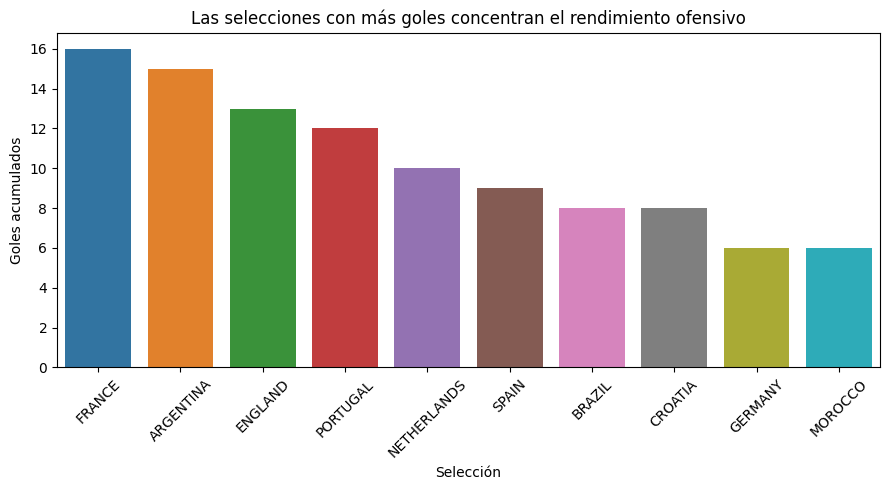

Figura guardada: results/figures/f4_figura_1_top_goles.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
top_goles = ranking_goles.head(10)
sns.barplot(data=top_goles, x="team", y="goals", hue="team", legend=False, ax=ax)
ax.set_title("Las selecciones con más goles concentran el rendimiento ofensivo")
ax.set_xlabel("Selección")
ax.set_ylabel("Goles acumulados")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
fig_path_1 = FIGURES_DIR / "f4_figura_1_top_goles.png"
plt.savefig(fig_path_1, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada:", ruta_repo(fig_path_1))



**Interpretación.** El ranking permite identificar qué selecciones concentraron mayor producción ofensiva. Este hallazgo ayuda a conectar el objetivo del proyecto con una métrica clara y verificable: los goles acumulados.


### Visualización 2 — La mayoría de los partidos se concentra en marcadores de pocos goles

**Acto 2: conflicto.** Aunque algunos equipos acumulan muchos goles, los partidos individuales suelen concentrarse en marcadores bajos o moderados.


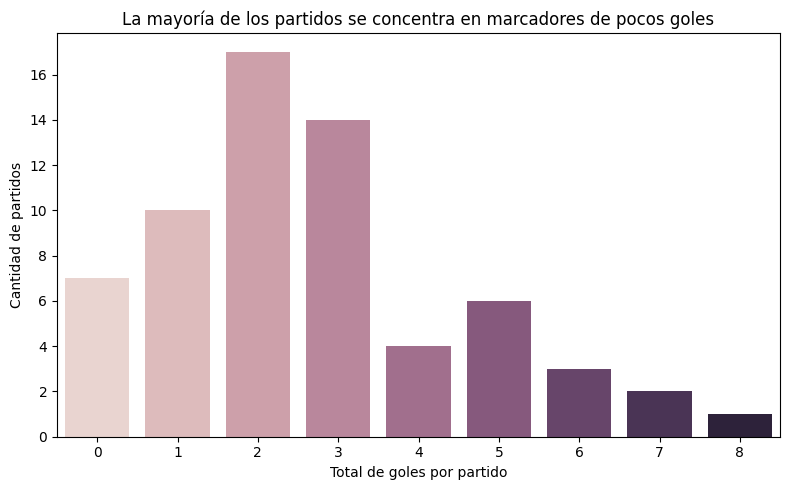

Figura guardada: results/figures/f4_figura_2_distribucion_goles.png


In [13]:
df_partidos = df_limpio.copy()
df_partidos["total goals match"] = pd.to_numeric(df_partidos["total goals match"], errors="coerce").fillna(0).astype(int)

conteo_goles = (
    df_partidos["total goals match"]
    .value_counts()
    .sort_index()
    .rename_axis("total_goals_match")
    .reset_index(name="cantidad_partidos")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=conteo_goles, x="total_goals_match", y="cantidad_partidos", hue="total_goals_match", legend=False, ax=ax)
ax.set_title("La mayoría de los partidos se concentra en marcadores de pocos goles")
ax.set_xlabel("Total de goles por partido")
ax.set_ylabel("Cantidad de partidos")
plt.tight_layout()
fig_path_2 = FIGURES_DIR / "f4_figura_2_distribucion_goles.png"
plt.savefig(fig_path_2, dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada:", ruta_repo(fig_path_2))



**Interpretación.** La distribución muestra que el rendimiento ofensivo no se reparte de forma uniforme entre partidos. Esto refuerza la necesidad de analizar tanto acumulados por equipo como comportamiento partido a partido.


### Visualización 3 — Mayor posesión no garantiza necesariamente más goles

**Acto 3: resolución.** Se contrasta una variable de control del juego con una variable de resultado ofensivo.


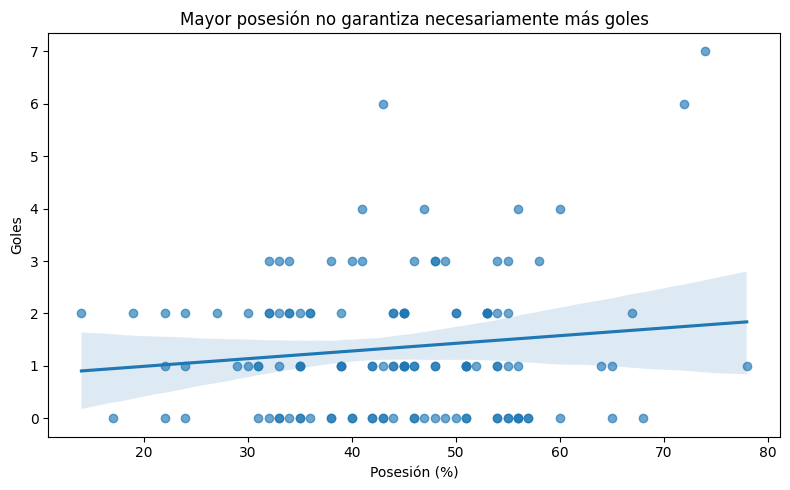

Figura guardada: results/figures/f4_figura_3_posesion_goles.png


In [14]:
df_pos = df_equipos.dropna(subset=["possession", "goals"]).copy()

if not df_pos.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.regplot(data=df_pos, x="possession", y="goals", ax=ax, scatter_kws={"alpha": 0.65})
    ax.set_title("Mayor posesión no garantiza necesariamente más goles")
    ax.set_xlabel("Posesión (%)")
    ax.set_ylabel("Goles")
    plt.tight_layout()
    fig_path_3 = FIGURES_DIR / "f4_figura_3_posesion_goles.png"
    plt.savefig(fig_path_3, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", ruta_repo(fig_path_3))
else:
    print("No hay datos suficientes de posesión para graficar.")


**Interpretación.** La posesión puede aportar contexto, pero no debe interpretarse como causa directa de goles. El análisis es descriptivo: permite observar asociaciones visuales, no demostrar causalidad.


### Visualización 4 complementaria — Correlación entre variables de rendimiento

Esta figura complementaria permite revisar asociaciones lineales entre goles, intentos, pases y posesión.


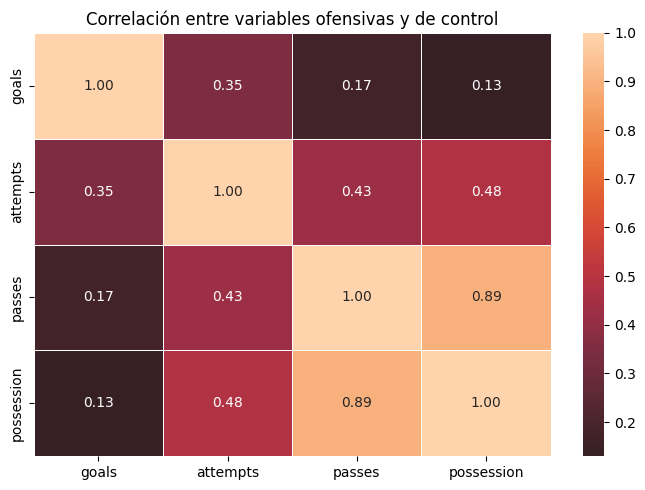

Figura guardada: results/figures/f4_figura_4_correlaciones.png


In [15]:
df_corr = df_equipos[["goals", "attempts", "passes", "possession"]].dropna(axis=1, how="all")
if df_corr.shape[1] >= 2:
    matriz_corr = df_corr.corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(matriz_corr, annot=True, fmt=".2f", center=0, linewidths=0.5, ax=ax)
    ax.set_title("Correlación entre variables ofensivas y de control")
    plt.tight_layout()
    fig_path_4 = FIGURES_DIR / "f4_figura_4_correlaciones.png"
    plt.savefig(fig_path_4, dpi=150, bbox_inches="tight")
    plt.show()
    print("Figura guardada:", ruta_repo(fig_path_4))
else:
    print("No hay suficientes variables numéricas para construir el mapa de calor.")


<a id="7"></a>
## 7. Metodología, trazabilidad de mejoras y *changelog*

La metodología sigue la progresión F1–F4: definición del problema, preparación de datos, desarrollo algorítmico y comunicación de resultados. La rúbrica solicita evidenciar la evolución del proyecto, por lo que se incluye una tabla de trazabilidad y la generación de un archivo `CHANGELOG.md`.


In [16]:
trazabilidad = pd.DataFrame([
    {
        "fase": "F1",
        "observacion": "Era necesario definir problema, pregunta, objetivos y entorno reproducible.",
        "mejora_aplicada": "Se formuló la pregunta orientadora, objetivos, alcance y estructura inicial del repositorio.",
        "impacto": "Entrega coherencia metodológica y punto de partida reproducible."
    },
    {
        "fase": "F2",
        "observacion": "El dataset requería limpieza, transformación y validación.",
        "mejora_aplicada": "Se creó pipeline con normalización, conversión de porcentajes, variables derivadas, imputación, codificación y validaciones.",
        "impacto": "Asegura datos consistentes para análisis posteriores."
    },
    {
        "fase": "F3",
        "observacion": "Se requería demostrar eficiencia algorítmica, recursividad y POO.",
        "mejora_aplicada": "Se incorporaron algoritmos iterativos, recursivos, vectorizados, merge sort, timeit y clases con herencia/polimorfismo.",
        "impacto": "Mejora la argumentación técnica y la mantenibilidad."
    },
    {
        "fase": "F4",
        "observacion": "Faltaba comunicar resultados con storytelling y trazabilidad final.",
        "mejora_aplicada": "Se agregaron visualizaciones, resultados, discusión, conclusiones, tabla de mejoras y generación de CHANGELOG.",
        "impacto": "Fortalece la comunicación profesional y el cierre ABP."
    },
])
trazabilidad


,fase,observacion,mejora_aplicada,impacto
0,F1,"Era necesario definir problema, pregunta, obje...","Se formuló la pregunta orientadora, objetivos,...",Entrega coherencia metodológica y punto de par...
1,F2,"El dataset requería limpieza, transformación y...","Se creó pipeline con normalización, conversión...",Asegura datos consistentes para análisis poste...
2,F3,"Se requería demostrar eficiencia algorítmica, ...","Se incorporaron algoritmos iterativos, recursi...",Mejora la argumentación técnica y la mantenibi...
3,F4,Faltaba comunicar resultados con storytelling ...,"Se agregaron visualizaciones, resultados, disc...",Fortalece la comunicación profesional y el cie...


In [17]:
changelog_path = PROJECT_ROOT / "CHANGELOG.md"
contenido_changelog = """# CHANGELOG

## [F4] - Proyecto final integrador
### Added
- Notebook `F4_Definicion_FINAL.ipynb` integrando F1, F2, F3 y F4.
- Tres visualizaciones analíticas principales y una visualización complementaria.
- Validaciones de casos normales, límite y excepciones.
- Mediciones de eficiencia con `timeit`.
- Implementación POO con encapsulamiento, herencia y polimorfismo.
- Tabla de trazabilidad de mejoras F1-F4.

### Changed
- Consolidación del flujo reproducible completo.
- Refuerzo de la interpretación analítica y del storytelling visual.
- Organización del notebook como evidencia ejecutable para informe y presentación.

### Validation
- Ejecutar `Kernel -> Restart & Run All` antes de entregar.
- Verificar que las figuras se guarden en `results/figures/`.
- Verificar coherencia entre notebook, informe, README y repositorio.
"""
changelog_path.write_text(contenido_changelog, encoding="utf-8")
print("CHANGELOG creado/actualizado en:", ruta_repo(changelog_path))


CHANGELOG creado/actualizado en: CHANGELOG.md


<a id="8"></a>
## 8. Resultados y discusión

### Resultados

1. El pipeline de F2 dejó un dataset limpio, validado y apto para análisis algorítmico y visual.
2. Los algoritmos iterativo, recursivo y vectorizado entregaron resultados equivalentes para la suma de goles.
3. Las mediciones con `timeit` muestran diferencias prácticas de rendimiento, justificando el uso de operaciones vectorizadas y funciones optimizadas cuando corresponde.
4. La POO permitió organizar el preprocesamiento y el cálculo de goles mediante encapsulamiento, herencia y polimorfismo.
5. Las visualizaciones comunican tres hallazgos: concentración ofensiva por selección, distribución de goles por partido y relación no causal entre posesión y goles.

### Discusión

Los resultados son coherentes con un análisis exploratorio. El dataset permite observar patrones relevantes del torneo, pero no permite afirmar causalidad. Variables como lesiones, estrategia táctica, calidad del rival o contexto del partido no están completamente representadas en el dataset.

### Limitaciones y riesgos

- El análisis se limita al Mundial Qatar 2022.
- La calidad de las conclusiones depende de la calidad del dataset original.
- Las correlaciones y gráficos no demuestran causalidad.
- El dataset demo solo se usa como respaldo técnico; la entrega final debe ejecutarse preferentemente con el CSV real.


<a id="9"></a>
## 9. Conclusiones y reflexión crítica

La integración F1–F4 consolida un proyecto reproducible de ciencia de datos. El flujo completo conecta problema, datos, pipeline, algoritmos, eficiencia, POO y comunicación visual.

Desde el punto de vista técnico, las principales mejoras fueron la validación sistemática del dataset, la comparación de implementaciones mediante `timeit`, la incorporación de POO y la construcción de visualizaciones interpretadas. Estas decisiones fortalecen la trazabilidad, la claridad del código y la comunicación de hallazgos.

Como mejora futura, el proyecto podría extenderse incorporando más torneos, variables contextuales de los partidos y modelos predictivos. Sin embargo, para esta fase el alcance se mantiene descriptivo y reproducible, evitando conclusiones causales no respaldadas por los datos.


<a id="10"></a>
## 10. Bibliografía (APA 7)

- Grus, J. (2020). *Data Science from Scratch: First Principles with Python* (2nd ed.). O’Reilly Media.
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O’Reilly Media.
- pandas development team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/
- Python Software Foundation. (2024a). *The Python Standard Library*. https://docs.python.org/3/library/index.html
- Python Software Foundation. (2024b). *Data structures*. https://docs.python.org/3/tutorial/datastructures.html
- scikit-learn developers. (2024). *scikit-learn documentation*. https://scikit-learn.org/stable/
- Universidad Andrés Bello. (2024a). *MCDI500: Evaluación Sumativa 4 – Fase 4. Proyecto final integrador: análisis, reproducibilidad y comunicación de resultados*. Dr. Omar Salinas Silva. Material docente del curso.
- Universidad Andrés Bello. (2024b). *MCDI500: Guía de desarrollo – Sumativa 4 / Fase 4*. Dr. Omar Salinas Silva. Material docente del curso.
- VanderPlas, J. (2023). *Python Data Science Handbook* (2nd ed.). O’Reilly Media.
- Waskom, M. (2024). *seaborn documentation*. https://seaborn.pydata.org/




## Verificación final antes de entregar

- Ejecutar **Kernel → Restart & Run All**.
- Confirmar que el notebook corre sin errores.
- Confirmar que se generaron las figuras en `results/figures/`.
- Confirmar que se creó o actualizó `CHANGELOG.md`.
- Revisar que el README explique instalación, dependencias y ejecución.
- Alinear este notebook con el informe PDF y la presentación audiovisual.


In [18]:
print("Verificación final")
print("Filas dataset limpio:", df_limpio.shape[0])
print("Columnas dataset procesado:", df_procesado.shape[1])
print("Total goles validado:", resultado_vectorizado)
print("Figuras esperadas en:", ruta_repo(FIGURES_DIR))
print("Notebook F4 integrador listo para revisión final.")


Verificación final
Filas dataset limpio: 64
Columnas dataset procesado: 93
Total goles validado: 172
Figuras esperadas en: results/figures
Notebook F4 integrador listo para revisión final.
